**Amazon Product Review Sentiment Classification using BERT
Project Overview**

In this project, we build a three-class sentiment classifier (Positive / Neutral / Negative) on real Amazon product reviews using BERT (Bidirectional Encoder Representations from Transformers).

BERT is a state-of-the-art pre-trained language model developed by Google. Fine-tuning BERT on a downstream task like sentiment classification allows us to achieve high accuracy even with relatively small datasets.

Sentiment Label Mapping

In [2]:
import pandas as pd

df = pd.read_excel("Online Retail.xlsx")

**Dataset: Amazon India Product Reviews (amazon.csv)**
for sentiment analysis , Online Retail
Model: bert-base-uncased via HuggingFace Transformers

In [3]:
df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


**Data Cleaning**

In [4]:
df = df.dropna(subset=['CustomerID', 'Description'])

In [5]:
df['CustomerID'] = df['CustomerID'].astype(int)

In [6]:
df = df[~df['InvoiceNo'].astype(str).str.contains('C')]

In [7]:
df = df[df['Quantity'] > 0]

In [8]:
df = df[df['UnitPrice'] > 0]

In [9]:
df['Description'] = df['Description'].str.lower()
df['Description'] = df['Description'].str.strip()

In [10]:
df.rename(columns={
    'CustomerID': 'user_id',
    'Description': 'product_name',
    'UnitPrice': 'price'
}, inplace=True)

In [11]:
df = df[['user_id', 'InvoiceNo', 'product_name', 'Quantity', 'price', 'Country']]

In [12]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   user_id       397884 non-null  int64  
 1   InvoiceNo     397884 non-null  object 
 2   product_name  397884 non-null  object 
 3   Quantity      397884 non-null  int64  
 4   price         397884 non-null  float64
 5   Country       397884 non-null  object 
dtypes: float64(1), int64(2), object(3)
memory usage: 21.2+ MB


,user_id,InvoiceNo,product_name,Quantity,price,Country
0,17850,536365,white hanging heart t-light holder,6,2.55,United Kingdom
1,17850,536365,white metal lantern,6,3.39,United Kingdom
2,17850,536365,cream cupid hearts coat hanger,8,2.75,United Kingdom
3,17850,536365,knitted union flag hot water bottle,6,3.39,United Kingdom
4,17850,536365,red woolly hottie white heart.,6,3.39,United Kingdom


Transaction Dataset

In [13]:
transactions = df.groupby('InvoiceNo')['product_name'].apply(list)

In [14]:
transactions.head()

,product_name
InvoiceNo,
536365,"[white hanging heart t-light holder, white met..."
536366,"[hand warmer union jack, hand warmer red polka..."
536367,"[assorted colour bird ornament, poppy's playho..."
536368,"[jam making set with jars, red coat rack paris..."
536369,[bath building block word]


In [15]:
print(len(transactions))
print(transactions.iloc[0])

18532
['white hanging heart t-light holder', 'white metal lantern', 'cream cupid hearts coat hanger', 'knitted union flag hot water bottle', 'red woolly hottie white heart.', 'set 7 babushka nesting boxes', 'glass star frosted t-light holder']


In [16]:
print(max(len(x) for x in transactions))

542


** One-Hot Encoding**

In [17]:
from mlxtend.preprocessing import TransactionEncoder

# Convert the dataset into a list of transactions
transactions = df.groupby('InvoiceNo')['product_name'].apply(lambda x: list(set(x))).tolist()

# Initialize the TransactionEncoder
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)

# Convert to a DataFrame
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

# Display the encoded data
df_encoded.head()

,10 colour spaceboy pen,12 coloured party balloons,12 daisy pegs in wood box,12 egg house painted wood,12 hanging eggs hand painted,12 ivory rose peg place settings,12 message cards with envelopes,12 pencil small tube woodland,12 pencils small tube red retrospot,12 pencils small tube skull,...,zinc star t-light holder,zinc sweetheart soap dish,zinc sweetheart wire letter rack,zinc t-light holder star large,zinc t-light holder stars large,zinc t-light holder stars small,zinc top 2 door wooden shelf,zinc willie winkie candle stick,zinc wire kitchen organiser,zinc wire sweetheart letter tray
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [18]:
df_encoded.shape

(18532, 3866)

In [19]:
from mlxtend.preprocessing import TransactionEncoder

# Convert the dataset into a list of transactions
transactions = df.groupby('InvoiceNo')['product_name'].apply(lambda x: list(set(x))).tolist()

# Initialize the TransactionEncoder
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)

# Convert to a DataFrame
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

**Apriori**

identifying frequent itemsets using support
Generating association rules using confidence and lift


Apriori Implementation

In [20]:
from mlxtend.frequent_patterns import apriori

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [21]:
frequent_itemsets = apriori(df_encoded, min_support=0.01, use_colnames=True)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [22]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [23]:
frequent_itemsets = apriori(df_encoded, min_support=0.01, use_colnames=True)

In [24]:
frequent_itemsets = apriori(df_encoded, min_support=0.01, use_colnames=True)

In [25]:
frequent_itemsets.head()

,support,itemsets
0,0.013058,(10 colour spaceboy pen)
1,0.010091,(12 message cards with envelopes)
2,0.014893,(12 pencil small tube woodland)
3,0.016566,(12 pencils small tube red retrospot)
4,0.015703,(12 pencils small tube skull)


Association Rules

In [26]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(60 cake cases dolly girl design),(pack of 72 retrospot cake cases),0.019102,0.055526,0.010199,0.533898,9.615358,1.0,0.009138,2.026327,0.913448,0.158291,0.506496,0.358786
1,(pack of 72 retrospot cake cases),(60 cake cases dolly girl design),0.055526,0.019102,0.010199,0.183673,9.615358,1.0,0.009138,1.201600,0.948675,0.158291,0.167776,0.358786
2,(60 cake cases vintage christmas),(set of 20 vintage christmas napkins),0.025146,0.026387,0.010091,0.401288,15.207896,1.0,0.009427,1.626178,0.958343,0.243490,0.385061,0.391850
3,(set of 20 vintage christmas napkins),(60 cake cases vintage christmas),0.026387,0.025146,0.010091,0.382413,15.207896,1.0,0.009427,1.578489,0.959565,0.243490,0.366483,0.391850
4,(72 sweetheart fairy cake cases),(60 teatime fairy cake cases),0.027034,0.035452,0.011979,0.443114,12.498911,1.0,0.011021,1.732037,0.945555,0.237179,0.422645,0.390507


**the best rule**

In [27]:
rules_filtered = rules[
    (rules['lift'] > 2) &
    (rules['confidence'] > 0.3)
]

rules_filtered.sort_values(by='lift', ascending=False).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
536,(regency tea plate green),(regency tea plate pink),0.014569,0.012087,0.010900,0.748148,61.895899,1.0,0.010724,3.922595,0.998390,0.691781,0.745067,0.824967
537,(regency tea plate pink),(regency tea plate green),0.012087,0.014569,0.010900,0.901786,61.895899,1.0,0.010724,10.033475,0.995881,0.691781,0.900334,0.824967
904,(poppy's playhouse livingroom),"(poppy's playhouse kitchen, poppy's playhouse ...",0.013598,0.013706,0.010037,0.738095,53.851894,1.0,0.009850,3.765850,0.994960,0.581250,0.734456,0.735189
901,"(poppy's playhouse kitchen, poppy's playhouse ...",(poppy's playhouse livingroom),0.013706,0.013598,0.010037,0.732283,53.851894,1.0,0.009850,3.684501,0.995069,0.581250,0.728593,0.735189
530,(regency milk jug pink),(regency sugar bowl green),0.014677,0.014461,0.011116,0.757353,52.370391,1.0,0.010904,4.061613,0.995517,0.616766,0.753792,0.763005
531,(regency sugar bowl green),(regency milk jug pink),0.014461,0.014677,0.011116,0.768657,52.370391,1.0,0.010904,4.259137,0.995299,0.616766,0.765211,0.763005
900,"(poppy's playhouse kitchen, poppy's playhouse ...",(poppy's playhouse bedroom),0.011602,0.017052,0.010037,0.865116,50.735237,1.0,0.009839,7.287376,0.991796,0.539130,0.862776,0.726862
905,(poppy's playhouse bedroom),"(poppy's playhouse kitchen, poppy's playhouse ...",0.017052,0.011602,0.010037,0.588608,50.735237,1.0,0.009839,2.402569,0.997295,0.539130,0.583779,0.726862
541,(regency tea plate roses),(regency tea plate pink),0.017699,0.012087,0.010630,0.600610,49.689732,1.0,0.010416,2.473553,0.997531,0.554930,0.595723,0.740037
540,(regency tea plate pink),(regency tea plate roses),0.012087,0.017699,0.010630,0.879464,49.689732,1.0,0.010416,8.149459,0.991864,0.554930,0.877292,0.740037


**Recommendation System**

In [28]:
def recommend_clean(product, rules, top_n=5):
    recs = rules[rules['antecedents'].apply(lambda x: product in x)]

    recs = recs.sort_values(by=['lift', 'confidence'], ascending=False)


    recs = recs.drop_duplicates(subset=['consequents'])

    return recs[['consequents', 'confidence', 'lift']].head(top_n)

**Top-N recommendations**

In [31]:
recommend_clean("hand warmer union jack", rules, top_n=5)

,consequents,confidence,lift
135,(hand warmer scotty dog design),0.430839,16.951822
133,(hand warmer owl design),0.473923,15.354439


**FP-GROWTH**

The FP-Growth Algorithm is an improved version of Apriori designed for better efficiency.

In [30]:
from mlxtend.frequent_patterns import fpgrowth, association_rules

frequent_fp = fpgrowth(df_encoded, min_support=0.01, use_colnames=True)

print(frequent_fp.head())

rules_fp = association_rules(frequent_fp, metric="lift", min_threshold=1)

print(rules_fp.head())

    support                               itemsets
0  0.106357   (white hanging heart t-light holder)
1  0.017321       (red woolly hottie white heart.)
2  0.017213  (knitted union flag hot water bottle)
3  0.016026         (set 7 babushka nesting boxes)
4  0.013005       (cream cupid hearts coat hanger)
                            antecedents                      consequents  \
0              (hand warmer owl design)         (hand warmer union jack)   
1              (hand warmer union jack)         (hand warmer owl design)   
2       (hand warmer scotty dog design)         (hand warmer union jack)   
3              (hand warmer union jack)  (hand warmer scotty dog design)   
4  (white hanging heart t-light holder)  (assorted colour bird ornament)   

   antecedent support  consequent support   support  confidence       lift  \
0            0.030866            0.023797  0.011278    0.365385  15.354439   
1            0.023797            0.030866  0.011278    0.473923  15.354439   
2  

**page rank**

 to rank products or items based on their importance within a network (graph-based ranking).

In [32]:
pip install pandas numpy matplotlib seaborn networkx mlxtend openpyxl

In [33]:
print(df.columns)
print(df.head())
print(df.info())
print(df.isnull().sum())

Index(['user_id', 'InvoiceNo', 'product_name', 'Quantity', 'price', 'Country'], dtype='object')
   user_id InvoiceNo                         product_name  Quantity  price  \
0    17850    536365   white hanging heart t-light holder         6   2.55   
1    17850    536365                  white metal lantern         6   3.39   
2    17850    536365       cream cupid hearts coat hanger         8   2.75   
3    17850    536365  knitted union flag hot water bottle         6   3.39   
4    17850    536365       red woolly hottie white heart.         6   3.39   

          Country  
0  United Kingdom  
1  United Kingdom  
2  United Kingdom  
3  United Kingdom  
4  United Kingdom  
<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   user_id       397884 non-null  int64  
 1   InvoiceNo     397884 non-null  object 
 2   product_name  397884 non-null

In [34]:
df.dropna(subset=['user_id', 'product_name'], inplace=True)

In [35]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [36]:
df = df[(df['Quantity'] > 0) & (df['price'] > 0)]

In [37]:
df.drop_duplicates(inplace=True)

In [38]:
df['TotalPrice'] = df['Quantity'] * df['price']

In [39]:
top_products = df.groupby('product_name')['Quantity']\
.sum().sort_values(ascending=False).head(10)

print(top_products)

product_name
paper craft , little birdie           80995
medium ceramic top storage jar        77916
world war 2 gliders asstd designs     54319
jumbo bag red retrospot               46078
white hanging heart t-light holder    36706
assorted colour bird ornament         35263
pack of 72 retrospot cake cases       33670
popcorn holder                        30919
rabbit night light                    27153
mini paint set vintage                26076
Name: Quantity, dtype: int64


In [40]:
top_countries = df.groupby('Country')['TotalPrice']\
.sum().sort_values(ascending=False).head(10)

print(top_countries)

Country
United Kingdom    7284785.494
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: TotalPrice, dtype: float64


In [41]:
top_customers = df.groupby('user_id')['InvoiceNo']\
.nunique().sort_values(ascending=False).head(10)

print(top_customers)

user_id
12748    209
14911    201
17841    124
13089     97
14606     93
15311     91
12971     86
14646     73
16029     63
13408     62
Name: InvoiceNo, dtype: int64


In [42]:
import networkx as nx
from itertools import combinations

In [43]:
G = nx.Graph()

In [44]:
transactions = df.groupby('InvoiceNo')['product_name'].apply(list)

In [45]:
for products in transactions:
    unique_products = list(set(products))

    for pair in combinations(unique_products, 2):
        if G.has_edge(*pair):
            G[pair[0]][pair[1]]['weight'] += 1
        else:
            G.add_edge(pair[0], pair[1], weight=1)

In [46]:
pagerank_scores = nx.pagerank(G)

In [47]:
pagerank_df = pd.DataFrame(
    pagerank_scores.items(),
    columns=['Product', 'PageRank']
).sort_values(by='PageRank', ascending=False)

print(pagerank_df.head(10))

                                 Product  PageRank
3     white hanging heart t-light holder  0.003260
519             regency cakestand 3 tier  0.002625
58               lunch bag red retrospot  0.002412
136              jumbo bag red retrospot  0.002382
61       pack of 72 retrospot cake cases  0.002153
2138    set of 3 cake tins pantry design  0.002094
1379                       party bunting  0.002051
226            lunch bag spaceboy design  0.002009
16         assorted colour bird ornament  0.001994
280              lunch bag  black skull.  0.001988


**HITS**

Authorities → Important products (high demand or frequently referenced)
Hubs → Products that are strongly connected to many other products
 in this project:
Detect influential products (authorities)
Identify connector products (hubs) that lead to multiple recommendations

In [48]:
# =========================
# HITS Algorithm
# =========================

hubs, authorities = nx.hits(G)

hits_df = pd.DataFrame({
    'Product': list(hubs.keys()),
    'HubScore': list(hubs.values()),
    'AuthorityScore': list(authorities.values())
})

top_authorities = hits_df.sort_values(
    by='AuthorityScore',
    ascending=False
)

print("Top Authority Products:")
print(top_authorities.head(10))


top_hubs = hits_df.sort_values(
    by='HubScore',
    ascending=False
)

print("Top Hub Products:")
print(top_hubs.head(10))

Top Authority Products:
                                 Product  HubScore  AuthorityScore
3     white hanging heart t-light holder  0.003946        0.003946
58               lunch bag red retrospot  0.003779        0.003779
136              jumbo bag red retrospot  0.003660        0.003660
519             regency cakestand 3 tier  0.003103        0.003103
280              lunch bag  black skull.  0.003090        0.003090
226            lunch bag spaceboy design  0.003071        0.003071
268                  lunch bag cars blue  0.002935        0.002935
61       pack of 72 retrospot cake cases  0.002860        0.002860
233              lunch bag pink polkadot  0.002858        0.002858
2748               lunch bag suki design  0.002808        0.002808
Top Hub Products:
                                 Product  HubScore  AuthorityScore
3     white hanging heart t-light holder  0.003946        0.003946
58               lunch bag red retrospot  0.003779        0.003779
136              jum

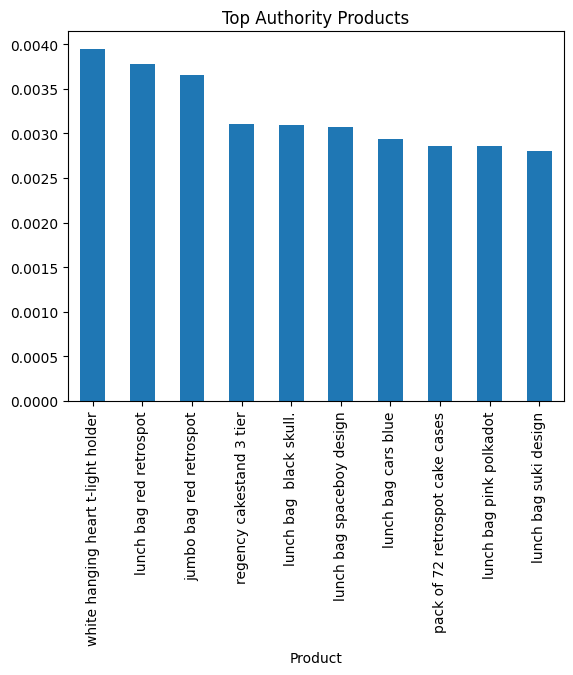

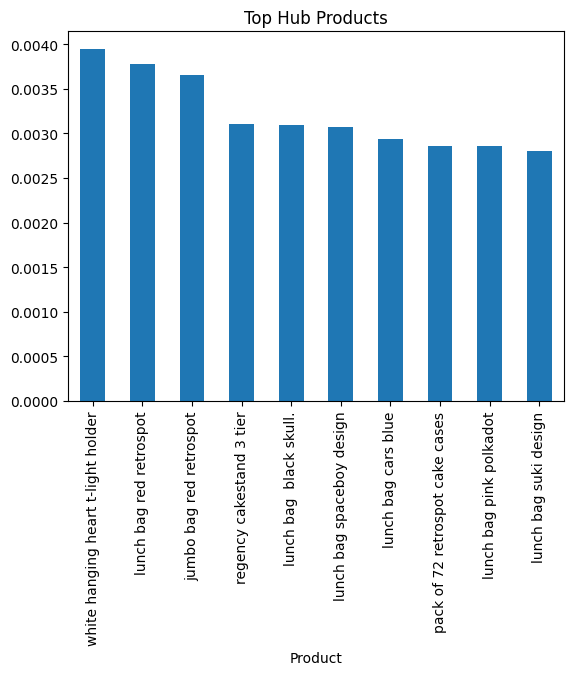

In [49]:
import matplotlib.pyplot as plt

# =========================
# HITS Visualization
# =========================

top_authorities.head(10).set_index('Product')[
    'AuthorityScore'
].plot(kind='bar')

plt.title("Top Authority Products")
plt.show()


top_hubs.head(10).set_index('Product')[
    'HubScore'
].plot(kind='bar')

plt.title("Top Hub Products")
plt.show()

In [50]:
hubs, authorities = nx.hits(G)

In [52]:
recommendations = list(G.neighbors(
    'white hanging heart t-light holder'
))

print(recommendations[:10])

['white metal lantern', 'set 7 babushka nesting boxes', 'cream cupid hearts coat hanger', 'glass star frosted t-light holder', 'knitted union flag hot water bottle', 'red woolly hottie white heart.', 'vintage billboard drink me mug', 'vintage billboard love/hate mug', 'wooden picture frame white finish', 'save the planet mug']


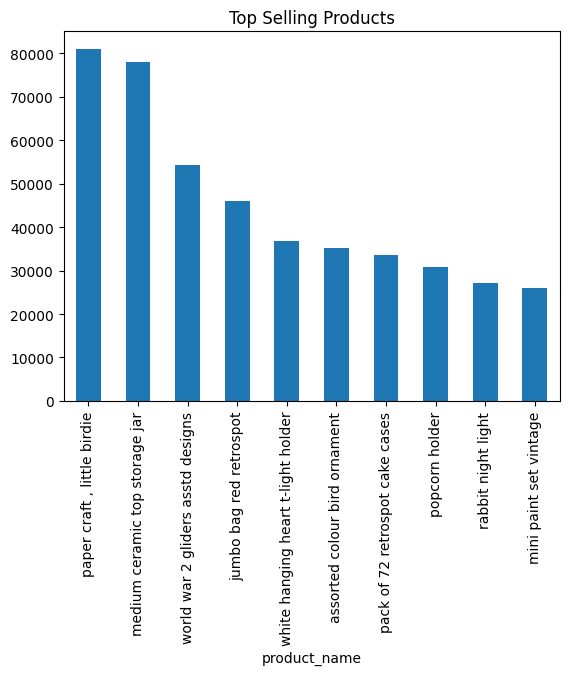

In [53]:
import matplotlib.pyplot as plt

top_products.plot(kind='bar')
plt.title("Top Selling Products")
plt.show()

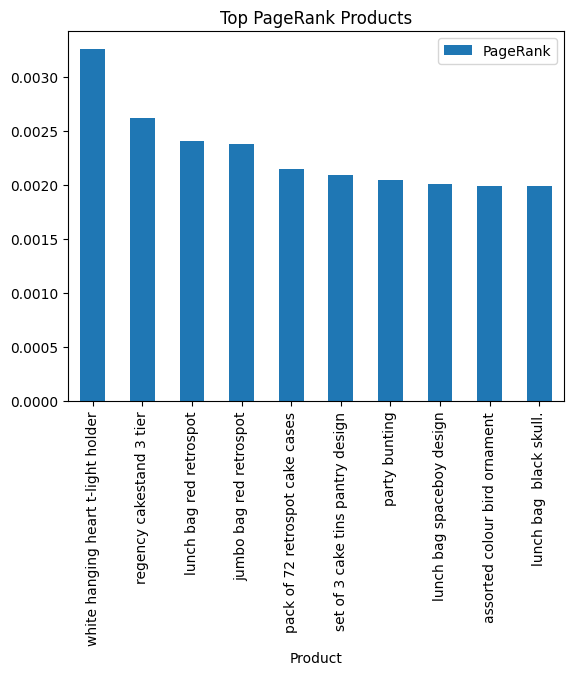

In [54]:
pagerank_df.head(10).set_index('Product')\
.plot(kind='bar')

plt.title("Top PageRank Products")
plt.show()

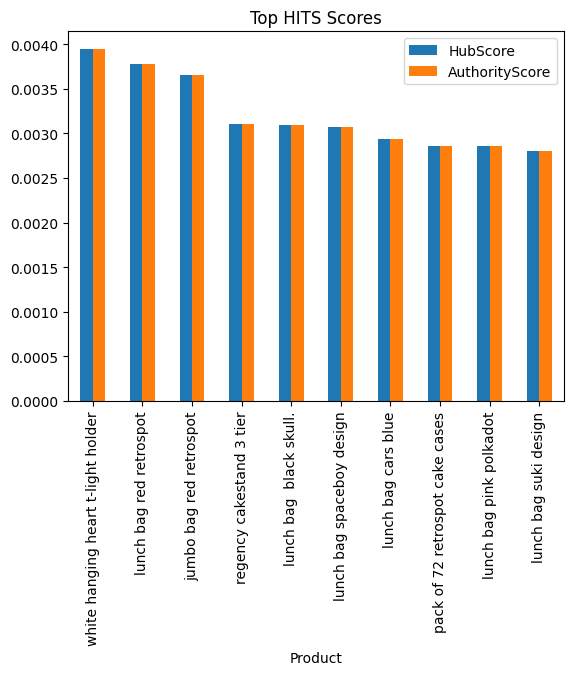

In [55]:
hits_df.head(10).set_index('Product')\
[['HubScore', 'AuthorityScore']]\
.plot(kind='bar')

plt.title("Top HITS Scores")
plt.show()

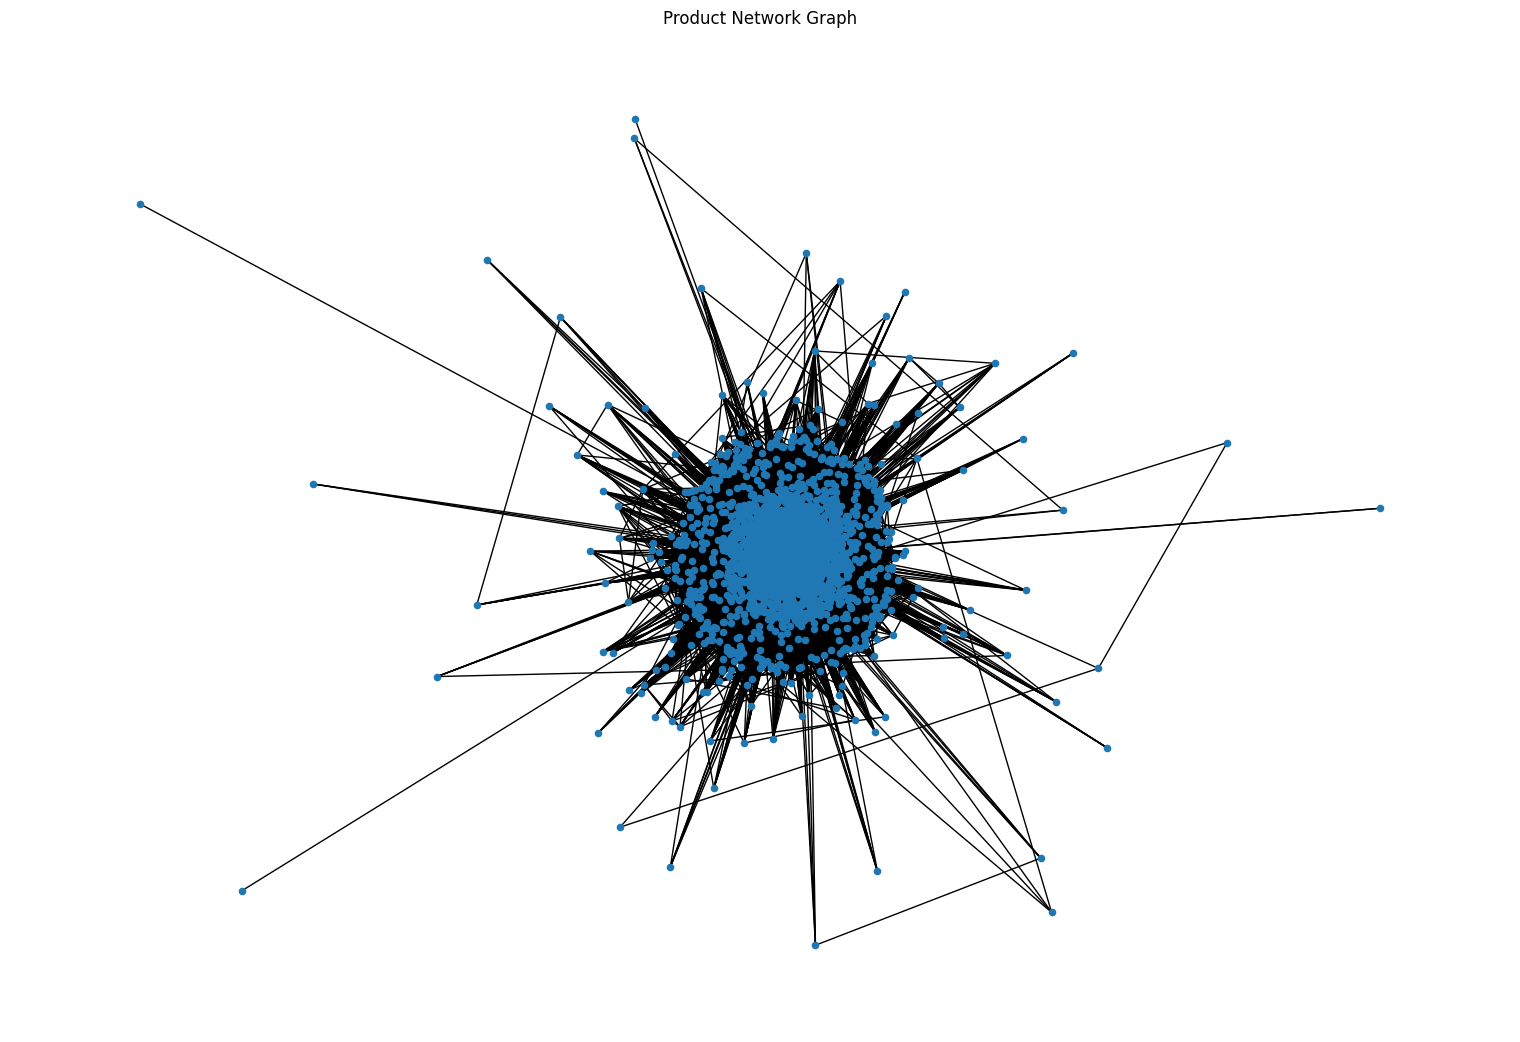

In [60]:
plt.figure(figsize=(15,10))
nx.draw(G, node_size=20, with_labels=False)
plt.title("Product Network Graph")
plt.show()

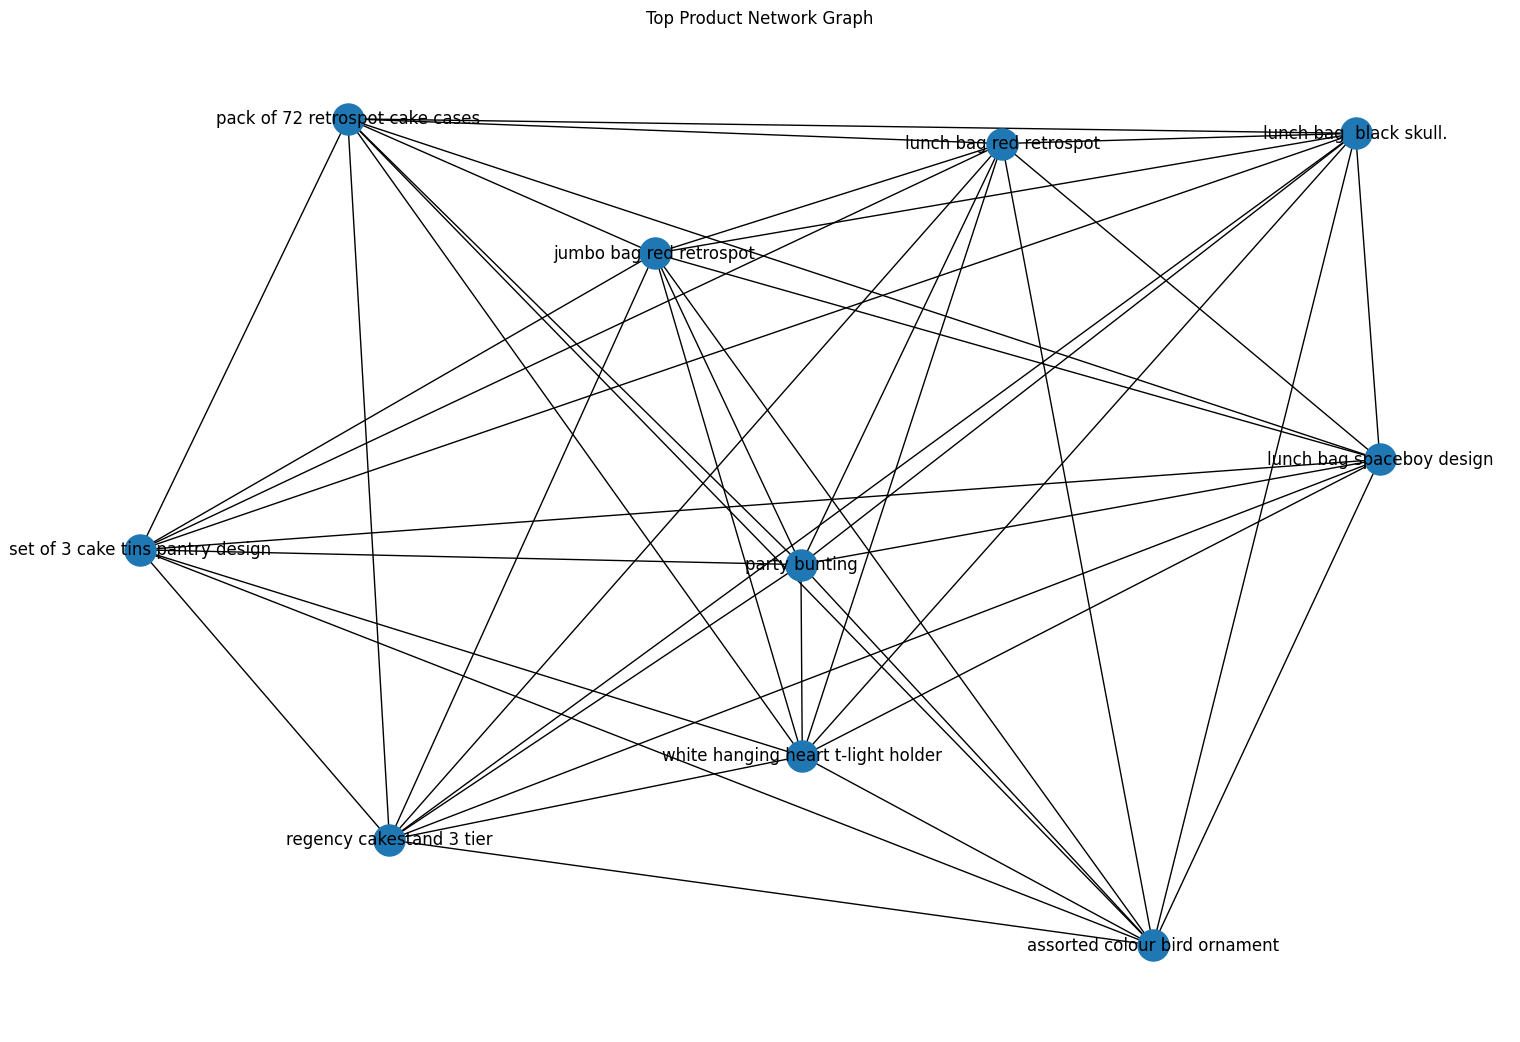

In [57]:
top_nodes = pagerank_df.head(10)['Product']

subgraph = G.subgraph(top_nodes)

plt.figure(figsize=(15,10))

nx.draw(
    subgraph,
    with_labels=True,
    node_size=500
)

plt.title("Top Product Network Graph")
plt.show()

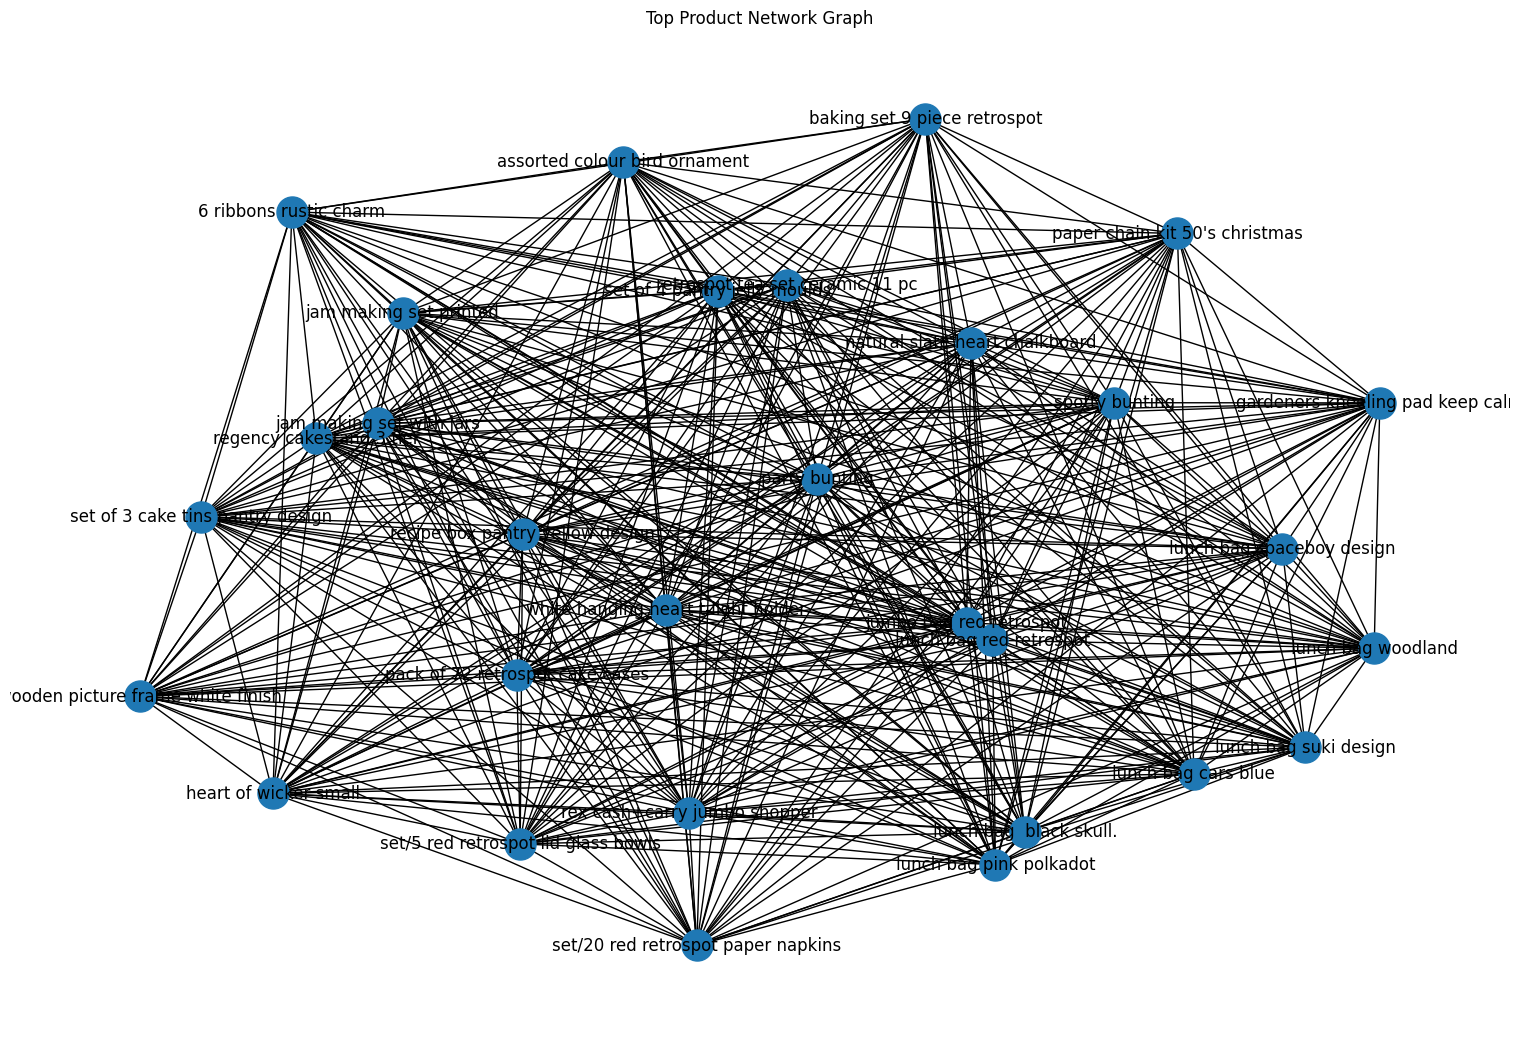

In [58]:
top_nodes = pagerank_df.head(30)['Product']

subgraph = G.subgraph(top_nodes)

plt.figure(figsize=(15,10))

nx.draw(
    subgraph,
    with_labels=True,
    node_size=500
)

plt.title("Top Product Network Graph")
plt.show()

In [ ]:
rules = pd.read_csv("apriori_rules.csv")

In [ ]:
fp_growth= pd.read_csv("fp_rules.csv")

In [ ]:
pagerank = pd.read_csv("pagerank_results.csv")

In [ ]:
import pickle

with open("graph.pkl", "rb") as f:
    G = pickle.load(f)